# SalesInsight PY — Análise e Visualização de Dados de Vendas

## RF01 – Criar ou Carregar o Dataset de Vendas

In [28]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

def gerar_dataset_vendas(n_registros=200, seed=42):
    """Gera um dataset sintetico de vendas com dados sujos."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor",
                "Teclado", "Mouse", "Headset"]
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares",
                  "Tablet": "Celulares", "Monitor": "Computadores",
                  "Teclado": "Perifericos", "Mouse": "Perifericos",
                  "Headset": "Perifericos"}
    precos = {"Notebook": 3500, "Smartphone": 2200, "Tablet": 1800,
              "Monitor": 1200, "Teclado": 250, "Mouse": 120,
              "Headset": 350}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]

    data_inicio = datetime(2025, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        categoria = categorias[produto]
        quantidade = random.randint(1, 10)
        preco = round(precos[produto] * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))
        data_txt = data.strftime("%Y-%m-%d")
        cliente = f"Cliente_{random.randint(1, 50):03d}"

        # --- sujeira proposital para a etapa de limpeza ---
        if random.random() < 0.05:
            quantidade = None                    # valor nulo
        if random.random() < 0.04:
            preco = None                         # valor nulo
        if random.random() < 0.06:
            produto = "  " + produto + " "       # espacos extras
        if random.random() < 0.03:
            data_txt = "DATA INVALIDA"           # data invalida
        if random.random() < 0.10:
            cliente = random.choice([            # ruido no nome
                cliente.upper().replace("_", "-"),
                cliente + "!!",
                "  " + cliente,
                cliente.replace("Cliente_", "cliente#"),
            ])

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_txt,
            "cliente": cliente,
            "produto": produto,
            "categoria": categoria,
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco,
        })

    return pd.DataFrame(dados)


# Gerar e salvar o CSV bruto
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head())


Dataset gerado com 200 registros.
   id_venda  data_venda      cliente   produto     categoria        regiao  \
0         1  2025-05-21  cliente#016     Mouse   Perifericos       Sudeste   
1         2  2025-09-16  Cliente_039  Notebook  Computadores         Norte   
2         3  2025-03-23  Cliente_045    Tablet     Celulares  Centro-Oeste   
3         4  2025-11-06  Cliente_017  Notebook  Computadores         Norte   
4         5  2025-07-05  Cliente_037    Tablet     Celulares           Sul   

   quantidade  preco_unitario  
0         2.0          102.90  
1         NaN         3204.57  
2         1.0         1939.76  
3         6.0         3864.87  
4        10.0         2008.14  


## RF02 – Inspecionar e Descrever os Dados

In [29]:
def inspecionar_dados(df):
    print("\n=== INSPECAO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    return df

inspecionar_dados(df_bruto)


=== INSPECAO INICIAL DO DATASET ===
Shape: (200, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade        10
preco_unitario     4
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente   produto     categoria        regiao  \
0         1  2025-05-21  cliente#016     Mouse   Perifericos       Sudeste   
1         2  2025-09-16  Cliente_039  Notebook  Computadores         Norte   
2         3  2025-03-23  Cliente_045    Tablet     Celulares  Centro-Oeste   
3         4  2025-11-06  Cliente_017  Notebook  Comp

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2025-05-21,cliente#016,Mouse,Perifericos,Sudeste,2.0,102.90
1,2,2025-09-16,Cliente_039,Notebook,Computadores,Norte,NaN,3204.57
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14
...,...,...,...,...,...,...,...,...
195,196,2025-06-04,CLIENTE-038,Monitor,Computadores,Centro-Oeste,5.0,NaN
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3.0,1748.92
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3.0,2185.60
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4.0,368.94


## RF03 – Limpar e Tratar os Dados (datetime e regex)

In [30]:
import re

def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.
    Retorna: (df_limpo, relatorio).
    """

    df = df.copy()
    registros_iniciais = len(df)

    # 1. Remover espaços extras das colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    for coluna in colunas_texto:
        df[coluna] = df[coluna].str.strip()

    # 2. Converter datas e remover datas inválidas
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    datas_invalidas = df["data_venda"].isna().sum()
    df = df.dropna(subset=["data_venda"])

    # 3. Remover nulos nas colunas críticas
    nulos_criticos = df[["quantidade", "preco_unitario"]].isna().any(axis=1).sum()
    df = df.dropna(subset=["quantidade", "preco_unitario"])

    # 4. Ajustar os tipos numéricos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # 5. Padronizar e sinalizar nomes de clientes
    padrao_cliente = re.compile(r"^Cliente_\d{3}$", flags=re.IGNORECASE)

    df["cliente_fora_padrao"] = ~df["cliente"].apply(
        lambda s: bool(padrao_cliente.fullmatch(str(s)))
    )

    def padronizar_cliente(nome):
        nome_limpo = re.sub(r"[^A-Za-z0-9]", "", str(nome).strip())
        numero = re.search(r"\d{3}", nome_limpo)

        if numero:
            return f"Cliente_{numero.group()}"
        return nome_limpo

    df["cliente"] = df["cliente"].apply(padronizar_cliente)

    # 6. Relatório de limpeza
    registros_finais = len(df)
    registros_removidos = registros_iniciais - registros_finais

    relatorio = {
        "registros_iniciais": registros_iniciais,
        "datas_invalidas_removidas": int(datas_invalidas),
        "nulos_criticos_removidos": int(nulos_criticos),
        "registros_removidos_total": registros_removidos,
        "registros_finais": registros_finais,
        "clientes_fora_padrao": int(df["cliente_fora_padrao"].sum())
    }

    print("\n=== RELATÓRIO DE LIMPEZA ===")
    for chave, valor in relatorio.items():
        print(f"{chave}: {valor}")

    return df, relatorio


df_limpo, relatorio = limpar_dados(df_bruto)


=== RELATÓRIO DE LIMPEZA ===
registros_iniciais: 200
datas_invalidas_removidas: 4
nulos_criticos_removidos: 13
registros_removidos_total: 17
registros_finais: 183
clientes_fora_padrao: 15


In [31]:
df_limpo[["cliente", "cliente_fora_padrao"]].head(20)

,cliente,cliente_fora_padrao
0,Cliente_016,True
2,Cliente_045,False
3,Cliente_017,False
4,Cliente_037,False
5,Cliente_041,False
6,Cliente_011,False
7,Cliente_021,False
8,Cliente_030,False
9,Cliente_033,False
11,Cliente_008,False


## RF04 – Criar Colunas Derivadas com Transformações Condicionais

In [32]:
def criar_colunas_derivadas(df):
    df = df.copy()

    # Receita total por linha
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Mês, ano e trimestre
    df["mes"] = df["data_venda"].dt.month
    df["ano"] = df["data_venda"].dt.year
    df["trimestre"] = "Q" + df["data_venda"].dt.quarter.astype(str)

    # Nome do mês em português
    meses = {
        1: "Janeiro",
        2: "Fevereiro",
        3: "Março",
        4: "Abril",
        5: "Maio",
        6: "Junho",
        7: "Julho",
        8: "Agosto",
        9: "Setembro",
        10: "Outubro",
        11: "Novembro",
        12: "Dezembro"
    }

    df["mes_nome"] = df["mes"].map(meses)

    # Classificação da receita por item
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]

    faixas = ["Baixo Valor", "Medio Valor", "Alto Valor"]

    df["faixa_receita_item"] = np.select(
        condicoes,
        faixas,
        default="Nao Classificado"
    )

    return df


df_analisado = criar_colunas_derivadas(df_limpo)

print(df_analisado.head())

   id_venda data_venda      cliente   produto     categoria        regiao  \
0         1 2025-05-21  Cliente_016     Mouse   Perifericos       Sudeste   
2         3 2025-03-23  Cliente_045    Tablet     Celulares  Centro-Oeste   
3         4 2025-11-06  Cliente_017  Notebook  Computadores         Norte   
4         5 2025-07-05  Cliente_037    Tablet     Celulares           Sul   
5         6 2025-08-21  Cliente_041   Headset   Perifericos       Sudeste   

   quantidade  preco_unitario  cliente_fora_padrao  receita_total  mes   ano  \
0           2          102.90                 True         205.80    5  2025   
2           1         1939.76                False        1939.76    3  2025   
3           6         3864.87                False       23189.22   11  2025   
4          10         2008.14                False       20081.40    7  2025   
5           2          337.41                False         674.82    8  2025   

  trimestre  mes_nome faixa_receita_item  
0        Q2  

## RF05 – Calcular Métricas Agregadas com groupby

In [33]:
def calcular_metricas(df):
    """Calcula as principais métricas agregadas do dataset."""

    metricas = {}

    # 1. Métricas por mês
    por_mes = (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade", "sum"),
            n_vendas=("id_venda", "count")
        )
        .reset_index()
    )

    metricas["por_mes"] = por_mes

    # 2. Receita total por produto - Top 5
    top_produtos = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    metricas["top_produtos"] = top_produtos

    # 3. Receita total por categoria
    por_categoria = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    metricas["por_categoria"] = por_categoria

    # 4. Receita total e ticket médio por região
    por_regiao = (
        df.groupby("regiao")
        .agg(
            receita_total=("receita_total", "sum"),
            ticket_medio=("receita_total", "mean")
        )
        .sort_values("receita_total", ascending=False)
        .reset_index()
    )

    metricas["por_regiao"] = por_regiao

    return metricas


metricas = calcular_metricas(df_analisado)

print("=== POR MES ===")
print(metricas["por_mes"])

print("\n=== TOP PRODUTOS ===")
print(metricas["top_produtos"])

print("\n=== POR CATEGORIA ===")
print(metricas["por_categoria"])

print("\n=== POR REGIAO ===")
print(metricas["por_regiao"])

=== POR MES ===
    mes  receita_total  quantidade  n_vendas
0     1      120866.25          92        15
1     2       73895.74          70        12
2     3      123869.23          98        18
3     4       80636.64          48         7
4     5      132080.62         104        19
5     6      106534.48          95        15
6     7      106667.30          84        14
7     8       85790.38          72        12
8     9       84081.59          89        17
9    10      110865.86          72        17
10   11      160297.77         136        23
11   12      104760.44          71        14

=== TOP PRODUTOS ===
      produto  receita_total
0    Notebook      374174.85
1      Tablet      335335.83
2  Smartphone      303255.94
3     Monitor      169554.67
4     Headset       48368.37

=== POR CATEGORIA ===
      categoria  receita_total
0     Celulares      638591.77
1  Computadores      543729.52
2   Perifericos      108025.01

=== POR REGIAO ===
         regiao  receita_total  tick

## RF06 – Segmentar Clientes por Nível de Gasto

In [34]:
def segmentar_clientes(df):
    """Agrupa os clientes, calcula o total gasto e classifica por segmento."""

    clientes = (
        df.groupby("cliente")["receita_total"]
        .sum()
        .reset_index(name="total_gasto")
    )

    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda valor: (
            "Bronze" if valor < 5000
            else "Prata" if valor <= 15000
            else "Ouro"
        )
    )

    return clientes


segmentacao_clientes = segmentar_clientes(df_analisado)

print("=== TOP 10 CLIENTES ===")
print(
    segmentacao_clientes
    .sort_values("total_gasto", ascending=False)
    .head(10)
)

print("\n=== DISTRIBUICAO POR SEGMENTO ===")
print(segmentacao_clientes["segmento"].value_counts())

=== TOP 10 CLIENTES ===
        cliente  total_gasto segmento
5   Cliente_006     65905.09     Ouro
35  Cliente_036     63433.04     Ouro
38  Cliente_039     59406.90     Ouro
19  Cliente_020     58459.54     Ouro
10  Cliente_011     56391.77     Ouro
33  Cliente_034     52035.60     Ouro
8   Cliente_009     50827.96     Ouro
23  Cliente_024     49146.94     Ouro
36  Cliente_037     46897.17     Ouro
18  Cliente_019     40731.05     Ouro

=== DISTRIBUICAO POR SEGMENTO ===
segmento
Ouro      34
Prata     10
Bronze     6
Name: count, dtype: int64


## RF07 – Operações Numéricas com NumPy

In [35]:
def analisar_numpy(df):
    """
    Converte colunas para arrays NumPy e calcula métricas de forma vetorizada,
    sem usar for/while (exigência do RF07).
    """

    # 1. .to_numpy() -> converte a coluna do pandas pra um array puro do NumPy
    receitas = df["receita_total"].to_numpy()
    quantidades = df["quantidade"].to_numpy()

    # 2. Funções de agregação do NumPy
    media_receita = np.mean(receitas)
    mediana_receita = np.median(receitas)
    desvio_padrao = np.std(receitas)
    receita_total_soma = np.sum(receitas)

    # 3. Broadcasting
    receitas_com_imposto = receitas * 1.05  # aplica 5% de imposto em TODAS as linhas de uma vez

    # 4. Filtragem Booleana
    mascara_altas = receitas > media_receita        # array de True/False
    receitas_acima_da_media = receitas[mascara_altas]  # só os valores True passam

    # organizando tudo num dicionário pra usar depois no relatório (RF10, JSON)
    estatisticas = {
        "media_receita": round(float(media_receita), 2),
        "mediana_receita": round(float(mediana_receita), 2),
        "desvio_padrao_receita": round(float(desvio_padrao), 2),
        "receita_total": round(float(receita_total_soma), 2),
        "qtd_transacoes_acima_da_media": int(mascara_altas.sum()),  # True = 1, então sum() conta quantos
    }

    return estatisticas


# executando
stats_numpy = analisar_numpy(df_analisado)

print("=== ESTATÍSTICAS NUMPY (RF07) ===")
for chave, valor in stats_numpy.items():
    print(f"{chave}: {valor}")

=== ESTATÍSTICAS NUMPY (RF07) ===
media_receita: 7051.07
mediana_receita: 3330.66
desvio_padrao_receita: 7809.92
receita_total: 1290346.3
qtd_transacoes_acima_da_media: 70


## RF08 – Criar Visualizações com Matplotlib e Seaborn

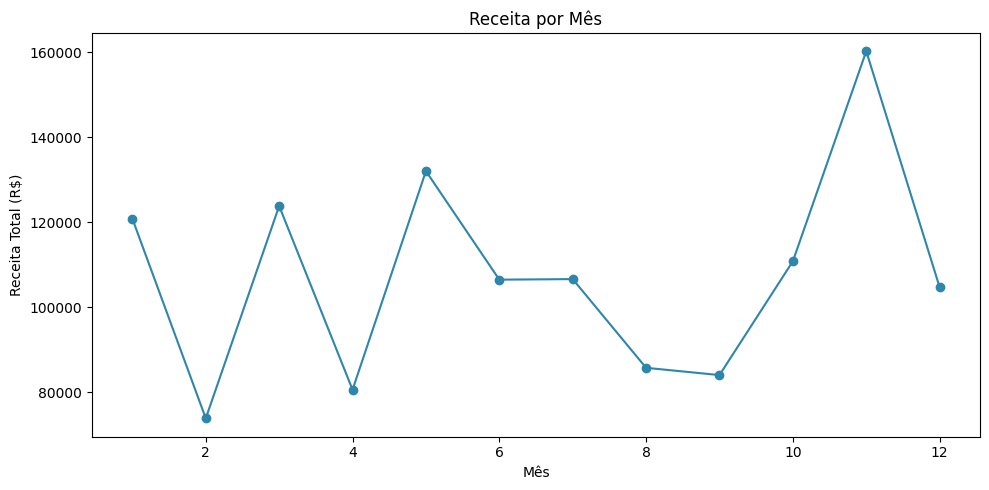

/tmp/ipykernel_681/2479736202.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


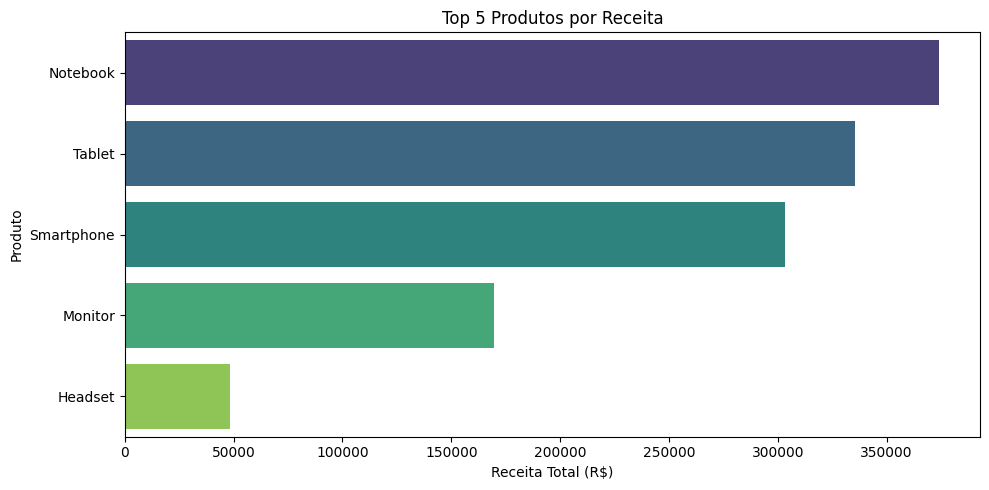

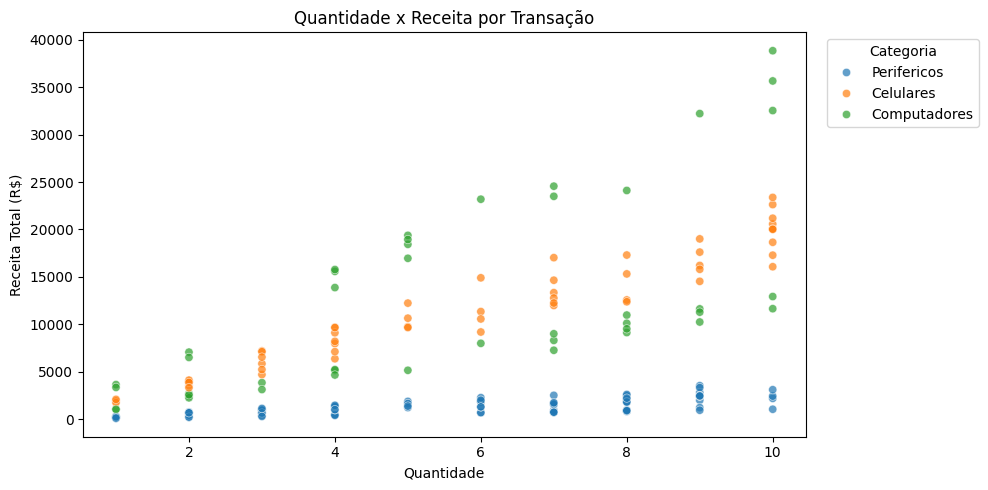

/tmp/ipykernel_681/2479736202.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=axs[0, 1], palette="viridis")
/tmp/ipykernel_681/2479736202.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita_regiao.index, y=receita_regiao.values, ax=axs[1, 1], palette="mako")


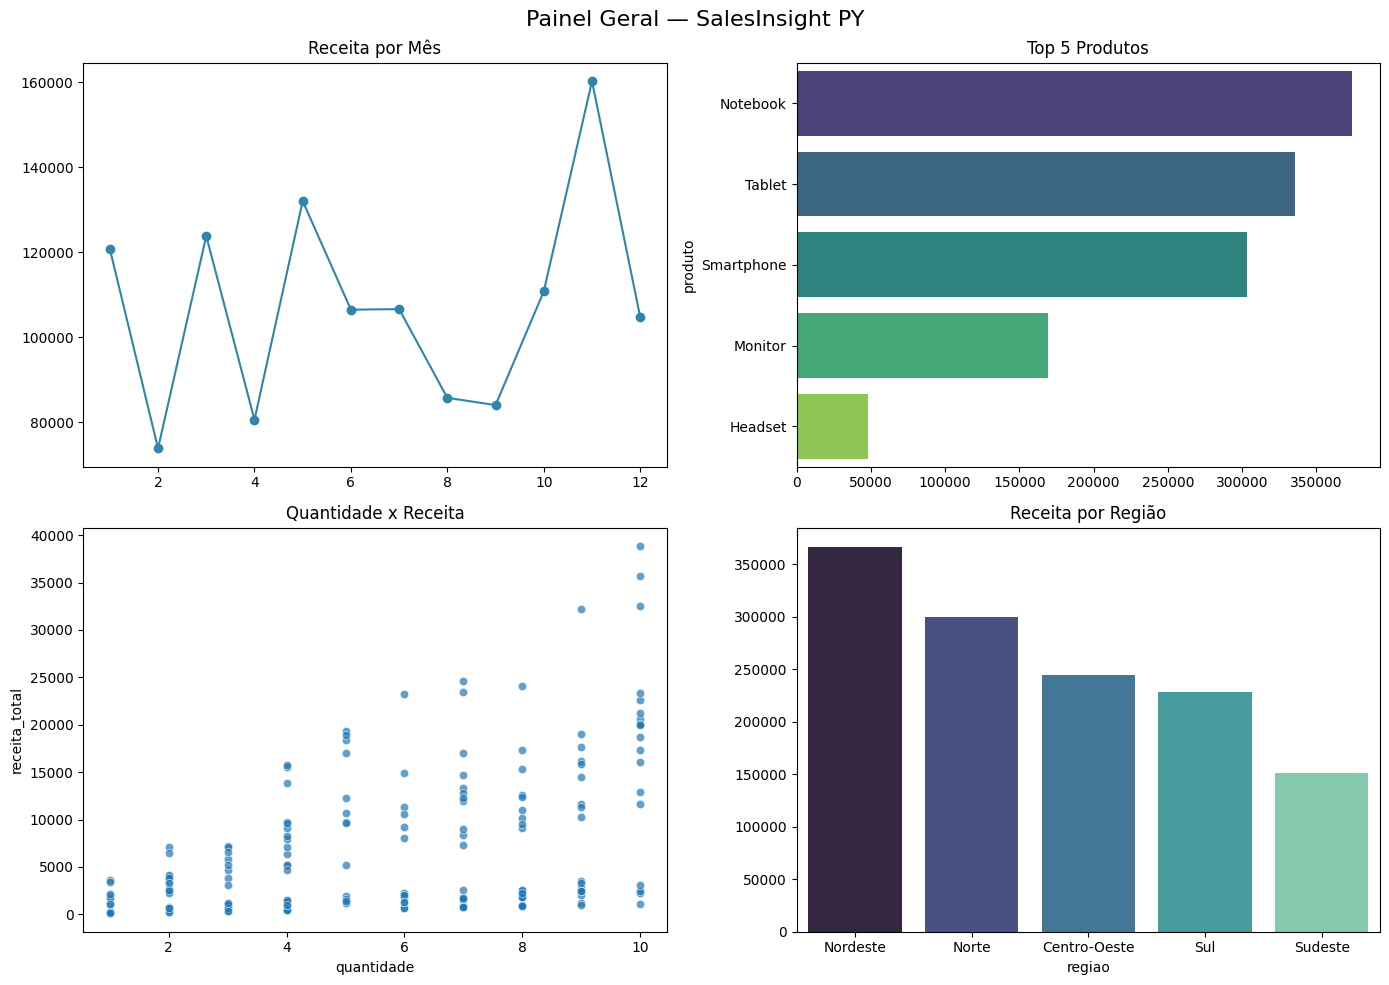

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def grafico_linha_receita_mes(df):
    receita_mes = df.groupby("mes")["receita_total"].sum().sort_index()
    plt.figure(figsize=(10, 5))
    plt.plot(receita_mes.index, receita_mes.values, marker="o", color="#2E86AB")
    plt.title("Receita por Mês")
    plt.xlabel("Mês")
    plt.ylabel("Receita Total (R$)")
    plt.tight_layout()
    plt.savefig("grafico_linha_receita_mes.png", dpi=100)
    plt.show()

def grafico_barras_top_produtos(df):
    top = df.groupby("produto")["receita_total"].sum().sort_values(ascending=False).head(5)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top.values, y=top.index, palette="viridis")
    plt.title("Top 5 Produtos por Receita")
    plt.xlabel("Receita Total (R$)")
    plt.ylabel("Produto")
    plt.tight_layout()
    plt.savefig("grafico_barras_top_produtos.png", dpi=100)
    plt.show()

def grafico_dispersao_qtd_receita(df):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x="quantidade", y="receita_total", hue="categoria", alpha=0.7)
    plt.title("Quantidade x Receita por Transação")
    plt.xlabel("Quantidade")
    plt.ylabel("Receita Total (R$)")
    plt.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("grafico_dispersao_qtd_receita.png", dpi=100)
    plt.show()

def painel_subplots(df):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    receita_mes = df.groupby("mes")["receita_total"].sum().sort_index()
    axs[0, 0].plot(receita_mes.index, receita_mes.values, marker="o", color="#2E86AB")
    axs[0, 0].set_title("Receita por Mês")

    top = df.groupby("produto")["receita_total"].sum().sort_values(ascending=False).head(5)
    sns.barplot(x=top.values, y=top.index, ax=axs[0, 1], palette="viridis")
    axs[0, 1].set_title("Top 5 Produtos")

    sns.scatterplot(data=df, x="quantidade", y="receita_total", ax=axs[1, 0], alpha=0.7)
    axs[1, 0].set_title("Quantidade x Receita")

    receita_regiao = df.groupby("regiao")["receita_total"].sum().sort_values(ascending=False)
    sns.barplot(x=receita_regiao.index, y=receita_regiao.values, ax=axs[1, 1], palette="mako")
    axs[1, 1].set_title("Receita por Região")

    fig.suptitle("Painel Geral — SalesInsight PY", fontsize=16)
    plt.tight_layout()
    plt.savefig("painel_subplots.png", dpi=100)
    plt.show()

grafico_linha_receita_mes(df_analisado)
grafico_barras_top_produtos(df_analisado)
grafico_dispersao_qtd_receita(df_analisado)
painel_subplots(df_analisado)

## RF09 – Organizar o Código em Funções Reutilizáveis e em uma Classe

In [37]:
# Recebe uma função como argumento (ex: np.mean)
def processar_coluna(df, coluna, funcao):
    return funcao(df[coluna])

class AnalisadorDeVendas:
    """Organiza o fluxo completo de análise de vendas."""

    def __init__(self, df):
        self.df = df
        self.estatisticas = {}
        self.segmentacao = None

    def limpar(self):
        self.df, self.relatorio_limpeza = limpar_dados(self.df)  # reaproveita a função do RF03
        return self.df

    def criar_colunas(self):                            # método novo adicionado
        self.df = criar_colunas_derivadas(self.df)
        return self.df

    def segmentar_clientes(self):
        self.segmentacao = segmentar_clientes(self.df)  # função do RF06
        return self.segmentacao

    def calcular_estatisticas_numpy(self):
        self.estatisticas = analisar_numpy(self.df)      # função do RF07
        return self.estatisticas

    def gerar_graficos(self):
        grafico_linha_receita_mes(self.df)
        grafico_barras_top_produtos(self.df)
        grafico_dispersao_qtd_receita(self.df)
        painel_subplots(self.df)

# exemplo de uso do processar_coluna, pra constar no notebook:
media_qtd = processar_coluna(df_analisado, "quantidade", np.mean)
print("Média de quantidade (via função de ordem superior):", media_qtd)

Média de quantidade (via função de ordem superior): 5.633879781420765


## RF10 – Exportar Resultados em CSV e JSON

In [38]:
import json

def exportar_resultados(df_segmentado, estatisticas, caminho_csv="relatorio_clientes.csv", caminho_json="estatisticas.json"):
    df_segmentado.to_csv(caminho_csv, index=False)

    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(estatisticas, f, indent=4, ensure_ascii=False)

    print(f"CSV exportado: {caminho_csv}")
    print(f"JSON exportado: {caminho_json}")

def reler_json(caminho_json="estatisticas.json"):
    with open(caminho_json, "r", encoding="utf-8") as f:
        dados = json.load(f)
    print("=== JSON RELIDO PARA CONFERÊNCIA ===")
    print(dados)
    return dados

## RF11 – Executar o Fluxo Completo (Ponto de Entrada)


=== RELATÓRIO DE LIMPEZA ===
registros_iniciais: 200
datas_invalidas_removidas: 4
nulos_criticos_removidos: 13
registros_removidos_total: 17
registros_finais: 183
clientes_fora_padrao: 15


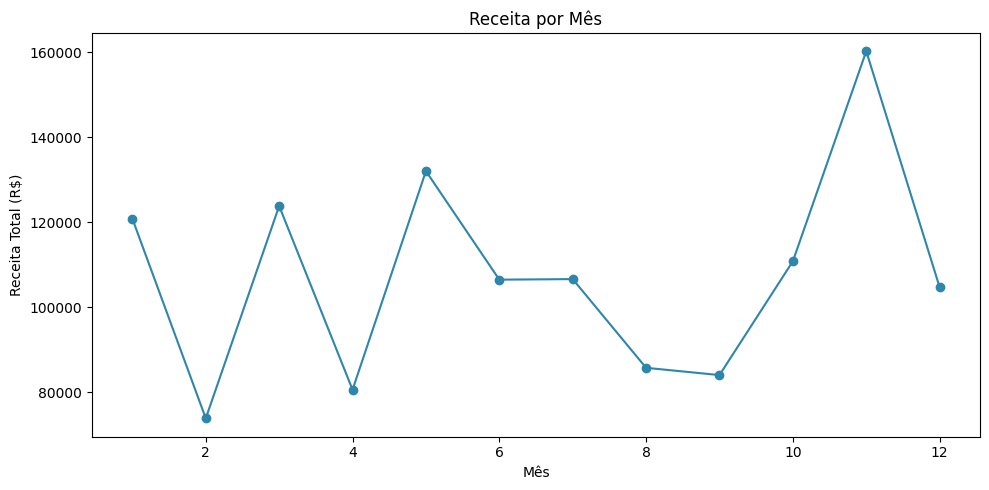

/tmp/ipykernel_681/2479736202.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


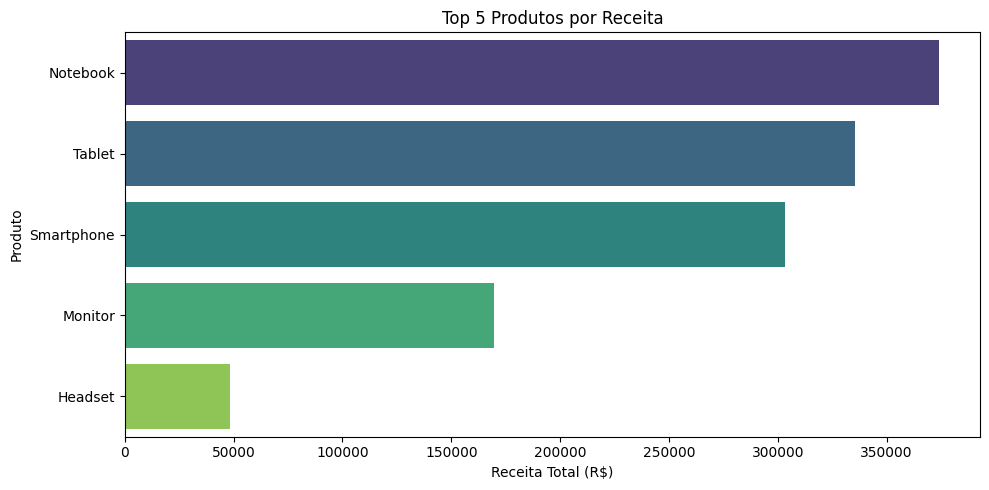

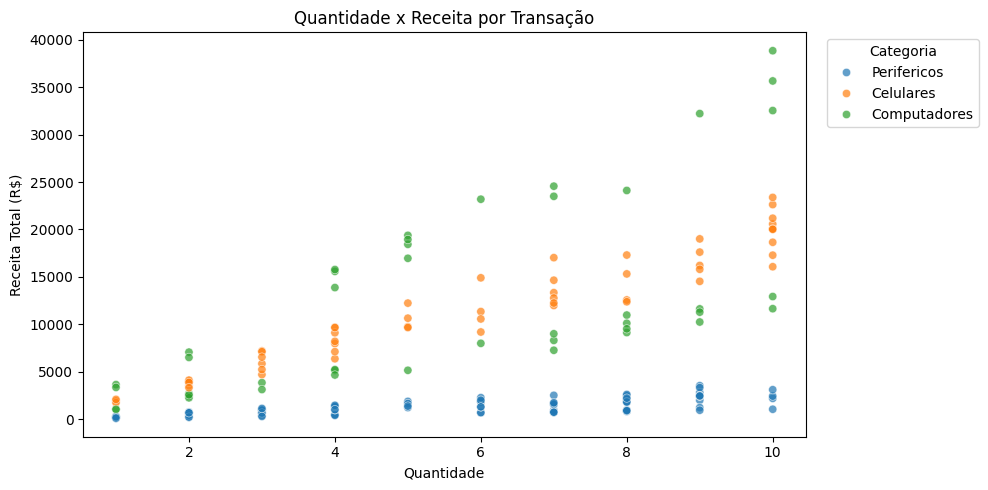

/tmp/ipykernel_681/2479736202.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=axs[0, 1], palette="viridis")
/tmp/ipykernel_681/2479736202.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita_regiao.index, y=receita_regiao.values, ax=axs[1, 1], palette="mako")


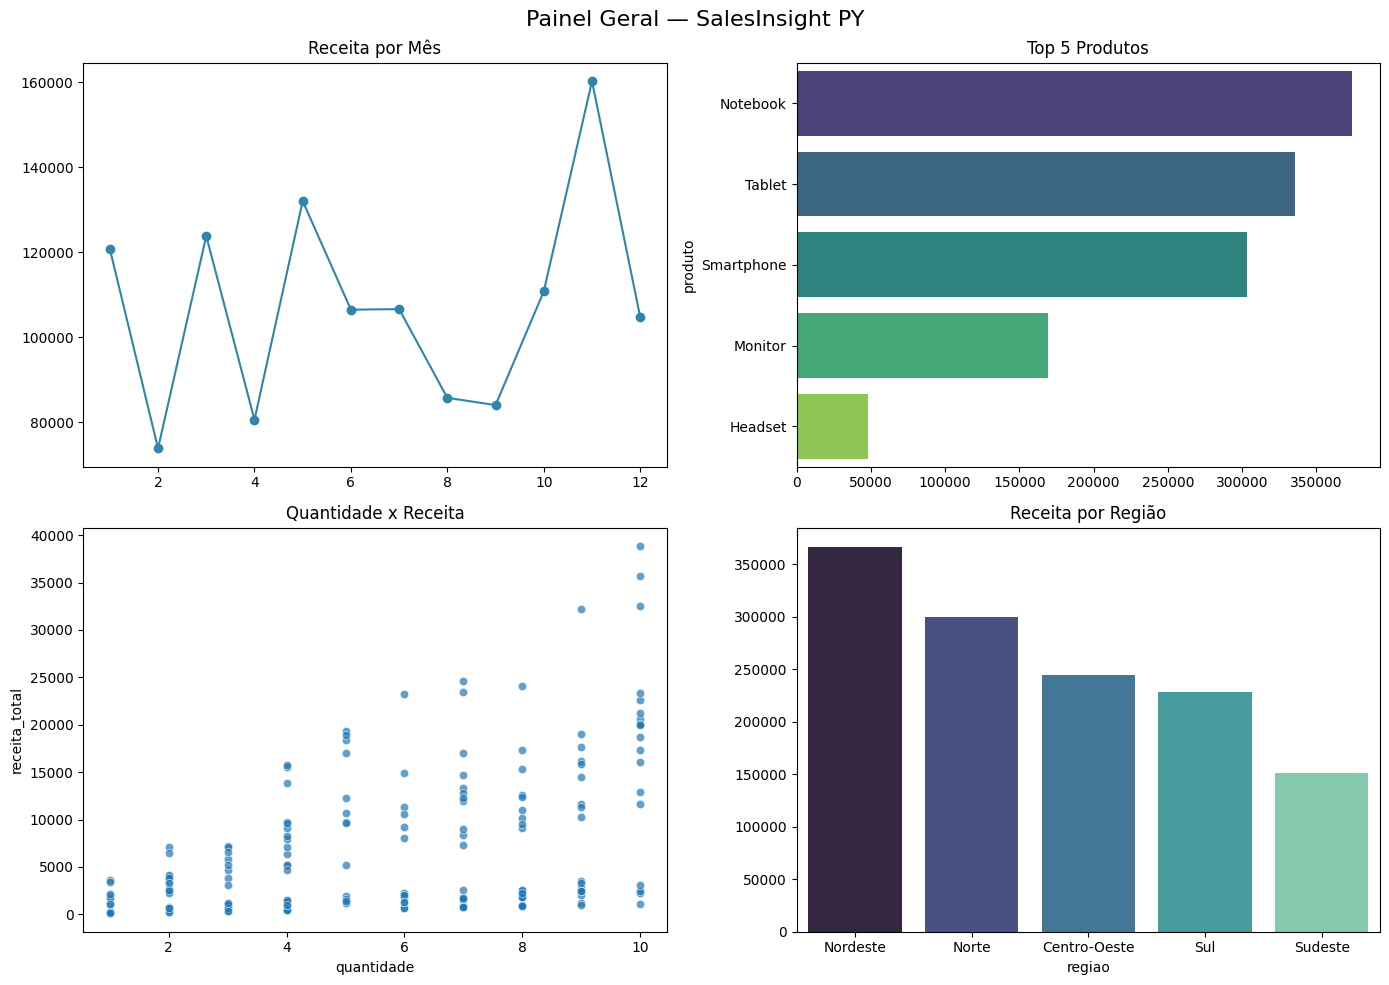

CSV exportado: relatorio_clientes.csv
JSON exportado: estatisticas.json
=== JSON RELIDO PARA CONFERÊNCIA ===
{'media_receita': 7051.07, 'mediana_receita': 3330.66, 'desvio_padrao_receita': 7809.92, 'receita_total': 1290346.3, 'qtd_transacoes_acima_da_media': 70, 'relatorio_limpeza': {'registros_iniciais': 200, 'datas_invalidas_removidas': 4, 'nulos_criticos_removidos': 13, 'registros_removidos_total': 17, 'registros_finais': 183, 'clientes_fora_padrao': 15}}
Fluxo executado com sucesso do início ao fim.


In [39]:
def main():
    analisador = AnalisadorDeVendas(df_bruto)
    analisador.limpar()
    analisador.criar_colunas()
    analisador.segmentar_clientes()
    analisador.calcular_estatisticas_numpy()
    analisador.gerar_graficos()

    analisador.estatisticas["relatorio_limpeza"] = analisador.relatorio_limpeza

    exportar_resultados(analisador.segmentacao, analisador.estatisticas)
    reler_json()

    print("Fluxo executado com sucesso do início ao fim.")

if __name__ == "__main__":
    main()

Receita por Trimestre

In [40]:
receita_por_trimestre = df_analisado.groupby("trimestre")["receita_total"].sum()

print("=== RECEITA POR TRIMESTRE ===")
print(receita_por_trimestre)

=== RECEITA POR TRIMESTRE ===
trimestre
Q1    318631.22
Q2    319251.74
Q3    276539.27
Q4    375924.07
Name: receita_total, dtype: float64
